<a href="https://colab.research.google.com/github/osh9149/2025_DataScience/blob/main/2025%EB%85%84_3%ED%95%99%EB%85%84_1%ED%95%99%EA%B8%B0_%EC%88%98%ED%96%89%ED%8F%89%EA%B0%80_%EC%97%B0%EC%8A%B5_%EB%B3%91%EC%9B%90%EC%A0%95%EB%B3%B4(%EC%A0%95%EB%8B%B5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

구글클래스 룸에서 2025병원데이터 다운로드
https://classroom.google.com/c/NzU2OTE3NjQxNTA5/p/Nzc4MjA3ODEyNTQ5/details


#공공데이터포털털에서 '2025_hopital.xlsx(전국병원 정보)'와 '2025_medicalbill(진료과목 별 의료비)'에 관한 파일을 다운받아 제공합니다.


#문제1. 폰트설치(1점) 후 런타임-> 다시 시작할 것

In [ ]:
#문제1번(1점)

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 34 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (21.1 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126102 files and direc

# 문제2. 데이터 분석 및 그래프, 지도 시각화를 위한 라이브러리를 호출(1점)

In [ ]:
#문제2번(1점)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium


#문제3번(1점). #2025_hopital.xlsx을 업로드함.  파일을 바로 업로드할 때(업로드는 1번만 실행할 것)(1점)

In [ ]:
#문제3번(1점)

from google.colab import files
f = files.upload()



Saving 2025_hospital.xlsx to 2025_hospital.xlsx


#문제4번(2점). 데이터파일을(2025_hopital.xlsx)을 판다스 라이브러리를 이용해 읽는다.

In [ ]:
#문제4번(2점)

df = pd.read_excel('2025_hospital.xlsx')
df




,요양기관명,종별코드,종별코드명,시도코드,시도코드명,주소,전화번호,총의사수,의과일반의 인원수,의과인턴 인원수,...,치과인턴 인원수,치과레지던트 인원수,치과전문의 인원수,한방일반의 인원수,한방인턴 인원수,한방레지던트 인원수,한방전문의 인원수,조산사 인원수,좌표(X),좌표(Y)
0,(사) 경찰공제회 포항의원,31,의원,370000,경북,"경상북도 포항시 남구 오천읍 냉천로 656, (오천읍)",054-292-6788,1,0,0,...,0,0,0,0,0,0,0,0,129.392904,35.942317
1,(사)경찰공제회남부의원,31,의원,220000,인천,"인천광역시 남동구 아암대로 1247, (고잔동)",032-811-2500,1,1,0,...,0,0,0,0,0,0,0,0,126.708861,37.384910
2,(사)대한결핵협회경기도지부부설복십자의원,31,의원,310000,경기,"경기도 수원시 팔달구 효원로 18, (매산로3가)",031-245-8671,1,0,0,...,0,0,0,0,0,0,0,0,127.008966,37.271984
3,(사)대한결핵협회전북특별자치도지부 복십자의원,31,의원,350000,전북,"전북특별자치도 전주시 덕진구 백제대로 789, (우아동3가, 복십자의원)",243-2724,1,0,0,...,0,0,0,0,0,0,0,0,127.154859,35.847700
4,(사)인구보건복지협회전북지회가족치과의원,51,치과의원,350000,전북,"전북특별자치도 전주시 덕진구 백제대로 722, 3층 (인후동2가)",063-240-2333,1,0,0,...,0,0,0,0,0,0,0,0,127.148116,35.844842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75969,학교법인가톨릭학원가톨릭대학교서울성모병원,1,상급종합,110000,서울,"서울특별시 서초구 반포대로 222, (반포동)",02-1588-1511,647,13,1,...,5,15,12,0,0,0,0,0,127.005115,37.500944
75970,삼성서울병원,1,상급종합,110000,서울,"서울특별시 강남구 일원로 81, (일원동, 삼성의료원)",02-3410-2114,918,19,25,...,0,4,14,0,0,0,0,0,127.085151,37.488298
75971,서울대학교병원,1,상급종합,110000,서울,"서울특별시 종로구 대학로 101, (연건동)",1588-5700,931,15,15,...,0,0,1,0,0,0,0,0,126.999017,37.579715
75972,연세대학교의과대학세브란스병원,1,상급종합,110000,서울,"서울특별시 서대문구 연세로 50-1, (신촌동)",02-2228-0114,941,21,11,...,0,0,0,0,0,0,0,0,126.940827,37.562345


#문제5번(2점).총의사수를 기준으로 내림차순으로 정렬하여 새로운 데이터프레임(df1)으로 만든다.


In [ ]:
#문제5번(2점)

df1=df.sort_values(by=['총의사수'], ascending=[False])
df1




,요양기관명,종별코드,종별코드명,시도코드,시도코드명,주소,전화번호,총의사수,의과일반의 인원수,의과인턴 인원수,...,치과인턴 인원수,치과레지던트 인원수,치과전문의 인원수,한방일반의 인원수,한방인턴 인원수,한방레지던트 인원수,한방전문의 인원수,조산사 인원수,좌표(X),좌표(Y)
75973,재단법인아산사회복지재단 서울아산병원,1,상급종합,110000,서울,"서울특별시 송파구 올림픽로43길 88, 서울아산병원 (풍납동)",02-3010-3114,1094,14,11,...,0,21,17,0,0,0,0,0,127.107935,37.526576
75972,연세대학교의과대학세브란스병원,1,상급종합,110000,서울,"서울특별시 서대문구 연세로 50-1, (신촌동)",02-2228-0114,941,21,11,...,0,0,0,0,0,0,0,0,126.940827,37.562345
75971,서울대학교병원,1,상급종합,110000,서울,"서울특별시 종로구 대학로 101, (연건동)",1588-5700,931,15,15,...,0,0,1,0,0,0,0,0,126.999017,37.579715
75970,삼성서울병원,1,상급종합,110000,서울,"서울특별시 강남구 일원로 81, (일원동, 삼성의료원)",02-3410-2114,918,19,25,...,0,4,14,0,0,0,0,0,127.085151,37.488298
75969,학교법인가톨릭학원가톨릭대학교서울성모병원,1,상급종합,110000,서울,"서울특별시 서초구 반포대로 222, (반포동)",02-1588-1511,647,13,1,...,5,15,12,0,0,0,0,0,127.005115,37.500944
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25334,서울이오스치과교정과치과의원,51,치과의원,110000,서울,"서울특별시 송파구 올림픽로35다길 42, 2층 (신천동, 한국루터회관)",02-3432-7528,1,0,0,...,0,0,0,0,0,0,0,0,127.102981,37.515287
25333,서울이엘치과의원,51,치과의원,310000,경기,"경기도 이천시 이섭대천로 1230-1, 3층 (창전동)",031-634-2804,1,0,0,...,0,0,0,0,0,0,0,0,127.447125,37.280124
25332,서울이앤이치과의원,51,치과의원,110000,서울,"서울특별시 동대문구 장한로 12, 2층 (장안동)",02-2243-2828,1,0,0,...,0,0,1,0,0,0,0,0,127.065690,37.562508
25331,서울이안치과의원,51,치과의원,310000,경기,"경기도 구리시 건원대로 44, 301호 (인창동, 태영빌딩)",031-551-5517,1,0,0,...,0,0,0,0,0,0,0,0,127.140488,37.605077


#문제6번(2점). 데이터프레임(d1f)에서 '총의사수'가 가장 많은 지역을 찾아 다음과 같이 출력한다.
예) 전국에서 총의사 수가 가장 많은 병원은 재단법인아산사회복지재단 서울아산병원입니다.  


In [ ]:
#문제6번(2점)

print('전국에서 총의사 수가 가장 많은 병원은 %s입니다.'%df1.loc[df1['총의사수'].idxmax(), '요양기관명'])


전국에서 총의사 수가 가장 많은 병원은 재단법인아산사회복지재단 서울아산병원입니다.


#문제7번(4점). 데이터프레임(df1)을 '시도코드명'으로 그룹화하여 count함수를 이용해 새로운 데이터프레임(df2)를 만든 후 df2를 '시도코드'를 기준으로 내림차순으로 정렬하여 df2를 출력한다.

In [ ]:
#문제7번(4점)

df2=df1.groupby('시도코드명').count()
df2=df2.sort_values(by=['시도코드'], ascending=[False])
df2


,요양기관명,종별코드,종별코드명,시도코드,주소,전화번호,총의사수,의과일반의 인원수,의과인턴 인원수,의과레지던트 인원수,...,치과인턴 인원수,치과레지던트 인원수,치과전문의 인원수,한방일반의 인원수,한방인턴 인원수,한방레지던트 인원수,한방전문의 인원수,조산사 인원수,좌표(X),좌표(Y)
시도코드명,,,,,,,,,,,,,,,,,,,,,
서울,19239,19239,19239,19239,19239,18981,19239,19239,19239,19239,...,19239,19239,19239,19239,19239,19239,19239,19239,18648,18648
경기,17535,17535,17535,17535,17535,17460,17535,17535,17535,17535,...,17535,17535,17535,17535,17535,17535,17535,17535,17110,17110
부산,5558,5558,5558,5558,5558,5529,5558,5558,5558,5558,...,5558,5558,5558,5558,5558,5558,5558,5558,5435,5435
대구,4156,4156,4156,4156,4156,4151,4156,4156,4156,4156,...,4156,4156,4156,4156,4156,4156,4156,4156,4048,4048
경남,3902,3902,3902,3902,3902,3885,3902,3902,3902,3902,...,3902,3902,3902,3902,3902,3902,3902,3902,3858,3858
인천,3807,3807,3807,3807,3807,3789,3807,3807,3807,3807,...,3807,3807,3807,3807,3807,3807,3807,3807,3713,3713
경북,3028,3028,3028,3028,3028,3013,3028,3028,3028,3028,...,3028,3028,3028,3028,3028,3028,3028,3028,2967,2967
전북,2627,2627,2627,2627,2627,2590,2627,2627,2627,2627,...,2627,2627,2627,2627,2627,2627,2627,2627,2602,2602
충남,2563,2563,2563,2563,2563,2550,2563,2563,2563,2563,...,2563,2563,2563,2563,2563,2563,2563,2563,2513,2513


#문제8번(4점). 위의 데이터프레임(df2)을 그래프로 그림처럼 시각화한다.
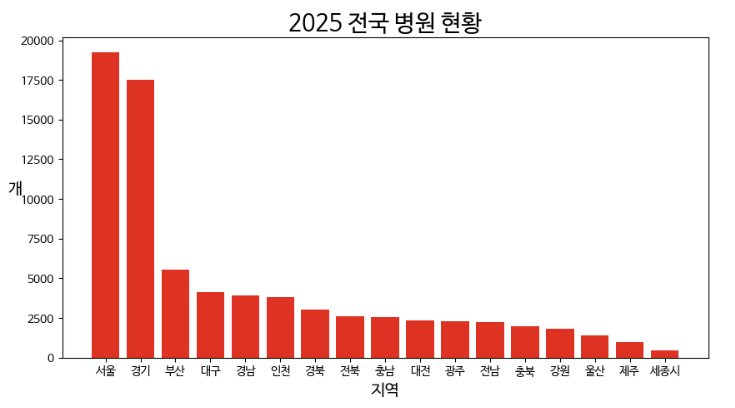

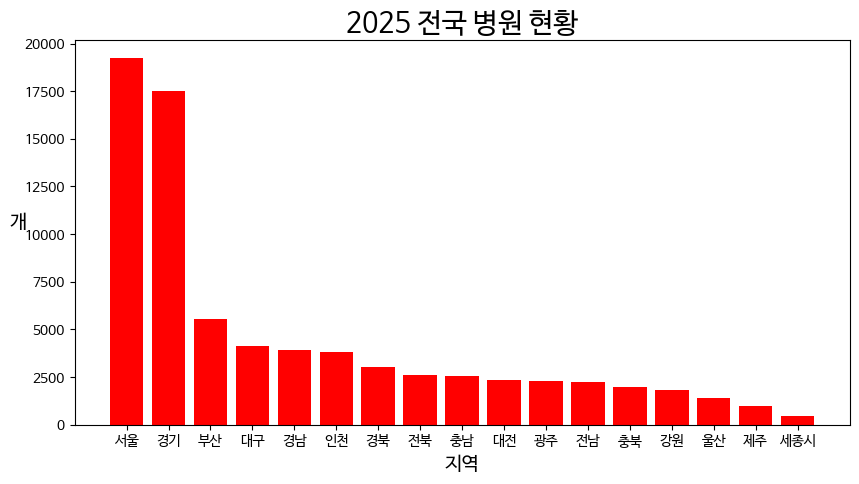

In [ ]:
#문제8번(4점)

plt.rc('font', family='NanumBarunGothic')
plt.figure(figsize=(10, 5))
plt.bar(df2.index, df2['시도코드'], color='red')

plt.title('2025 전국 병원 현황', fontsize=20)
plt.xlabel('지역', fontsize=14)
plt.ylabel('개',rotation='horizontal',fontsize=14)
plt.xticks(rotation=0)
plt.show()


#문제9번(4점). 데이터프레임(df)에서 원하는 지역의 이름을 입력받아 해당하는 지역에서 총의사수가 50명 이상인 병원의 데이터만 새로운 데이터프레임(df3)로 만든다.
예) '서울' 입력하여 확인

In [ ]:
#문제9번(4점)

name=input('지역을 입력하세요 : ')
df3=df[df['시도코드명'].str.contains(name, na=False) & (df['총의사수']>50)]
df3






지역을 입력하세요 : 서울


,요양기관명,종별코드,종별코드명,시도코드,시도코드명,주소,전화번호,총의사수,의과일반의 인원수,의과인턴 인원수,...,치과인턴 인원수,치과레지던트 인원수,치과전문의 인원수,한방일반의 인원수,한방인턴 인원수,한방레지던트 인원수,한방전문의 인원수,조산사 인원수,좌표(X),좌표(Y)
75781,서울특별시서남병원,11,종합병원,110000,서울,"서울특별시 양천구 신정이펜1로 20, (신정동)",1566-6688,52,0,0,...,0,0,1,0,0,0,0,0,126.833153,37.512020
75782,아이디병원,21,병원,110000,서울,"서울특별시 강남구 도산대로 142, 아이디병원 B1층,1,2,3층 (논현동)",02-547-0050,52,8,0,...,0,0,7,0,0,0,0,0,127.024188,37.517680
75784,홍익병원,11,종합병원,110000,서울,"서울특별시 양천구 목동로 225, 홍익병원본관 (신정동)",02-2693-5555,52,0,1,...,0,0,2,0,0,0,0,0,126.863655,37.528484
75788,세란병원,11,종합병원,110000,서울,"서울특별시 종로구 통일로 256, (무악동)",02-737-0181,54,6,0,...,0,0,0,0,0,0,0,0,126.957461,37.575184
75795,의료법인삼성의료재단 강북삼성태평로의원,31,의원,110000,서울,"서울특별시 중구 세종대로 67, 3층, 지하1,2층 (태평로2가)",02-2001-1140,56,2,0,...,0,0,0,0,0,0,0,0,126.975497,37.562444
75799,성애의료재단 성애병원,11,종합병원,110000,서울,"서울특별시 영등포구 여의대방로53길 22, (신길동, 성애병원)",02-840-7114,58,2,1,...,0,0,1,0,0,0,0,0,126.922500,37.512027
75809,부민병원,11,종합병원,110000,서울,"서울특별시 강서구 공항대로 389, 부민병원 (등촌동)",1577-7582,61,7,1,...,0,0,0,0,0,0,0,0,126.850927,37.556866
75811,미즈메디병원,11,종합병원,110000,서울,"서울특별시 강서구 강서로 295, (내발산동)",02-2007-1000,62,2,0,...,0,0,0,0,0,0,0,0,126.835936,37.552218
75812,서울대학교병원 강남의원,31,의원,110000,서울,"서울특별시 강남구 테헤란로 152, (역삼동, 강남파이낸스센터 38층,39층, 3층일부)",2112-5500,62,0,0,...,0,0,0,0,0,0,0,0,127.036546,37.500026
75828,자생한방병원,92,한방병원,110000,서울,"서울특별시 강남구 강남대로 536, 자생한방병원 (논현동)",02-1577-0007,71,0,0,...,0,0,0,4,8,31,21,0,127.022346,37.510010


#문제10번(4점). 데이터프레임(df3)에서 위도 경도를 찾아 지도에 마커로 표시(zoom_start=11)하고 팝업에 병원이름이 보이도록 한다.
아이콘 변경 -> icon=folium.Icon(icon = 'home', color='red')
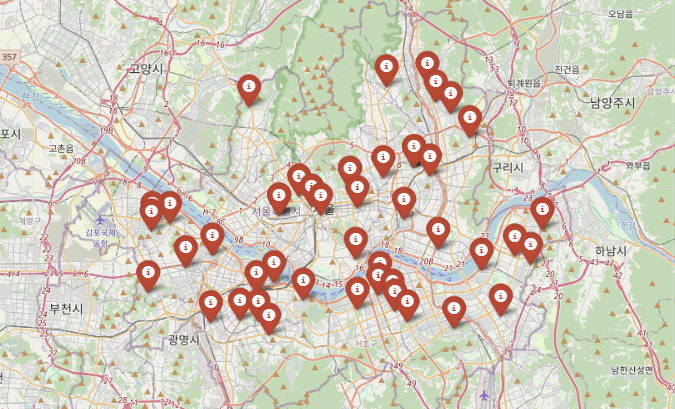

In [ ]:
#문제10번(4점)

lat = df3.loc[df3.index[0], '좌표(Y)']
lng = df3.loc[df3.index[0], '좌표(X)']

map = folium.Map(
    location=[lat,lng ], tiles ='OpenStreetMap' , zoom_start=11)

for idx in df3.index:

    lat = df3.loc[idx, '좌표(Y)']
    lng = df3.loc[idx, '좌표(X)']

    name = df3.loc[idx, '요양기관명']

    folium.Marker(
          location=[lat, lng],
          icon=folium.Icon(color='red'),
          popup=name
      ).add_to(map)

map



# 2025_medicalbill.csv --------------------------------------------




#문제11번(1점). 파일 '2025_medicalbill.csv'를 업로드한다.

In [ ]:
#문제11번(1점)
from google.colab import files
f = files.upload()





Saving 2025_medicalbill.csv to 2025_medicalbill.csv


#문제12번(1점). 파일 '2025_medicalbill.csv'를 업로드하고 파일을 읽어 데이터프레임(df)를 출력한다.

In [ ]:
#문제12번(1점)

df = pd.read_csv('2025_medicalbill.csv', encoding='cp949')
df

,진료년도,시도,진료과목,환자수,명세서청구건수,입내원일수,요양급여비용총액,보험자부담금
0,2023,서울,일반의,1738,2693,16148,3207471280,2642753210
1,2023,서울,내과,3112366,15424223,20044258,5322454856400,4372265575130
2,2023,서울,신경과,657946,2105615,3028174,506521229120,357578866240
3,2023,서울,정신건강의학과,220521,1161124,1708091,192408737620,133031051480
4,2023,서울,외과,999670,3287843,4947950,1767136303650,1509705410020
...,...,...,...,...,...,...,...,...
775,2023,세종,한방내과,1099,3246,1983,208890720,159241050
776,2023,세종,한방부인과,30,31,31,1404130,866430
777,2023,세종,한방안·이비인후·피부과,100,169,170,7078410,4352140
778,2023,세종,침구과,4478,12700,22680,1996543460,1502012160


#문제13번(2점). 데이터프레임(df)에서 '환자수'을 기준으로 내림차순으로 정렬한 후 df를 출력한다.

In [ ]:
#문제13번(2점)

df=df.sort_values(by=['환자수'], ascending=[False])
df


,진료년도,시도,진료과목,환자수,명세서청구건수,입내원일수,요양급여비용총액,보험자부담금
1,2023,서울,내과,3112366,15424223,20044258,5322454856400,4372265575130
330,2023,경기,내과,2695368,12276668,17305041,3357824857730,2680767077870
334,2023,경기,정형외과,1668010,6325444,8585653,1147797152570,845741140340
5,2023,서울,정형외과,1325220,4788308,6716080,1182671130840,875038929860
353,2023,경기,응급의학과,1139657,1516912,1635556,341784415460,226903659380
...,...,...,...,...,...,...,...,...
169,2023,대구,예방의학과,1,1,31,2499980,1833730
186,2023,대구,한방신경정신과,1,1,0,36970,29580
181,2023,대구,통합치의학과,1,3,0,23550,18840
95,2023,부산,한방소계,1,1,0,34920,27940


#문제14번(4점). 데이터프레임(df)에서 환자수가 가장 많은 시도와 보험자부담금을 출력합니다.
출력결과)병원 진료과목 중 환자수가 가장 많은 시도는 서울이고 보험자부담금은 4,372,265,575,130원입니다.

In [ ]:
#문제14번(4점)

name=df.loc[df['환자수'].idxmax()].시도
bill="{:,}".format(df.loc[df['환자수'].idxmax()].보험자부담금)

print('병원 진료과목 중 환자수가 가장 많은 시도는 %s이고 보험자부담금은 %s원입니다.'%(name, bill))


병원 진료과목 중 환자수가 가장 많은 시도는 서울이고 보험자부담금은 4,372,265,575,130원입니다.


#문제15번(4번). 데이터프레임(df)에서 '진료과목'으로 그룹하여 '환자수'를 기준으로 내림차순으로 정렬하여 새로운 데이터프레임 df1을 출력합니다.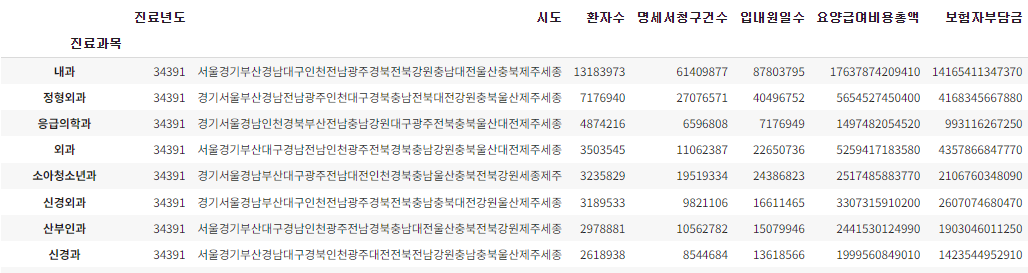

In [ ]:
#문제15번(4점)

#groupby('컬럼').count() : 개수
#groupby('컬럼').sum() : 합계
#groupby('컬럼').mean() : 평균

df1=df.groupby(df['진료과목']).sum()
# df3=df.groupby(df['진료과목']).sum().reset_index()
df1=df1.sort_values(by=['환자수'], ascending=[False])
df1


,진료년도,시도,환자수,명세서청구건수,입내원일수,요양급여비용총액,보험자부담금
진료과목,,,,,,,
내과,34391,서울경기부산경남대구인천전남광주경북전북강원충남대전울산충북제주세종,13183973,61409877,87803795,17637874209410,14165411347370
정형외과,34391,경기서울부산경남전남광주인천대구경북충남전북대전강원충북울산제주세종,7176940,27076571,40496752,5654527450400,4168345667880
응급의학과,34391,경기서울경남인천경북부산전남충남강원대구광주전북충북울산대전제주세종,4874216,6596808,7176949,1497482054520,993116267250
외과,34391,서울경기부산대구경남전남인천광주전북경북충남강원충북울산대전제주세종,3503545,11062387,22650736,5259417183580,4357866847770
소아청소년과,34391,경기서울경남부산대구광주전남대전인천경북충남울산충북전북강원세종제주,3235829,19519334,24386823,2517485883770,2106760348090
신경외과,34391,경기서울경남부산대구인천전남광주경북전북충남충북대전강원울산제주세종,3189533,9821106,16611465,3307315910200,2607074680470
산부인과,34391,서울경기부산대구경남인천광주전남경북충남대전울산충북전북강원제주세종,2978881,10562782,15079946,2441530124990,1903046011250
신경과,34391,서울경기부산경남대구경북인천광주대전전북전남강원충남충북울산제주세종,2618938,8544684,13618566,1999560849010,1423544952910
안과,34391,서울경기부산대구인천광주대전경남전북경북울산강원충남충북제주전남세종,2324446,6224080,6437987,1131120583430,739151030250


#문제16번(4점). 데이터프레임(df1)에서 내과 환자수와 외과 환자수의 차이를 계산하여 아래와 같이 출력한다. 이때 차이값은 print문에서 %d로 출력한다.(4점)
예) 내과의 환자수가 외과의 환자수보다 9680428명 많습니다.

In [ ]:
#문제14번(4점)
# df3[df3["진료과목"] == "내과"]["환자수"]
# df3.loc["내과", "환자수"] #진료과목이 인덱스일 때

num = "{:,}".format(df1.loc["내과", "환자수"]-df1.loc["외과", "환자수"])
print('내과의 환자수가 외과의 환자수보다 %s명 많습니다.'%(num))


내과의 환자수가 외과의 환자수보다 9,680,428명 많습니다.


#문제17번(4점). 데이터프레임(df)에서 진료과목이 성형외과이고 환자수가 1000명 이상인 데이터를 추출하여 새로운 데이터프레임 df2로 만든다.(3점)

In [ ]:
#문제17번(4점)

df2=df[(df['진료과목']=='성형외과') & (df['환자수']>1000)]
df2



,진료년도,시도,진료과목,환자수,명세서청구건수,입내원일수,요양급여비용총액,보험자부담금
8,2023,서울,성형외과,118316,412209,545639,94925980030,74017278770
337,2023,경기,성형외과,94437,312479,435732,69398938650,52887915180
151,2023,대구,성형외과,30104,88524,117335,20199144000,15139713790
625,2023,경북,성형외과,18999,47257,58821,7627241680,5345086570
247,2023,대전,성형외과,18227,65950,87459,11316982340,8342723540
673,2023,경남,성형외과,13657,39996,56294,7403084400,5478681870
482,2023,충남,성형외과,12753,38022,96315,13056771050,9535233400
56,2023,부산,성형외과,12349,46119,83142,15008364390,11576326710
105,2023,인천,성형외과,10140,35509,42189,5992596540,4326129180
433,2023,충북,성형외과,9256,35328,43908,4088321970,2901436230


#문제18번(4점). 위의 데이터프레임(df2)을 그래프로 그림처럼 시각화한다.
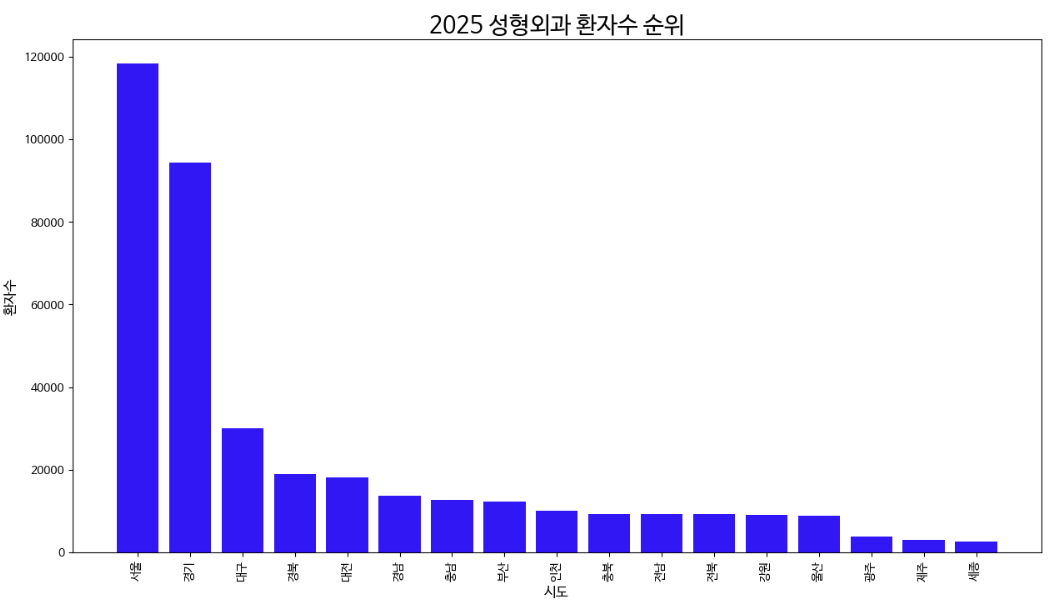

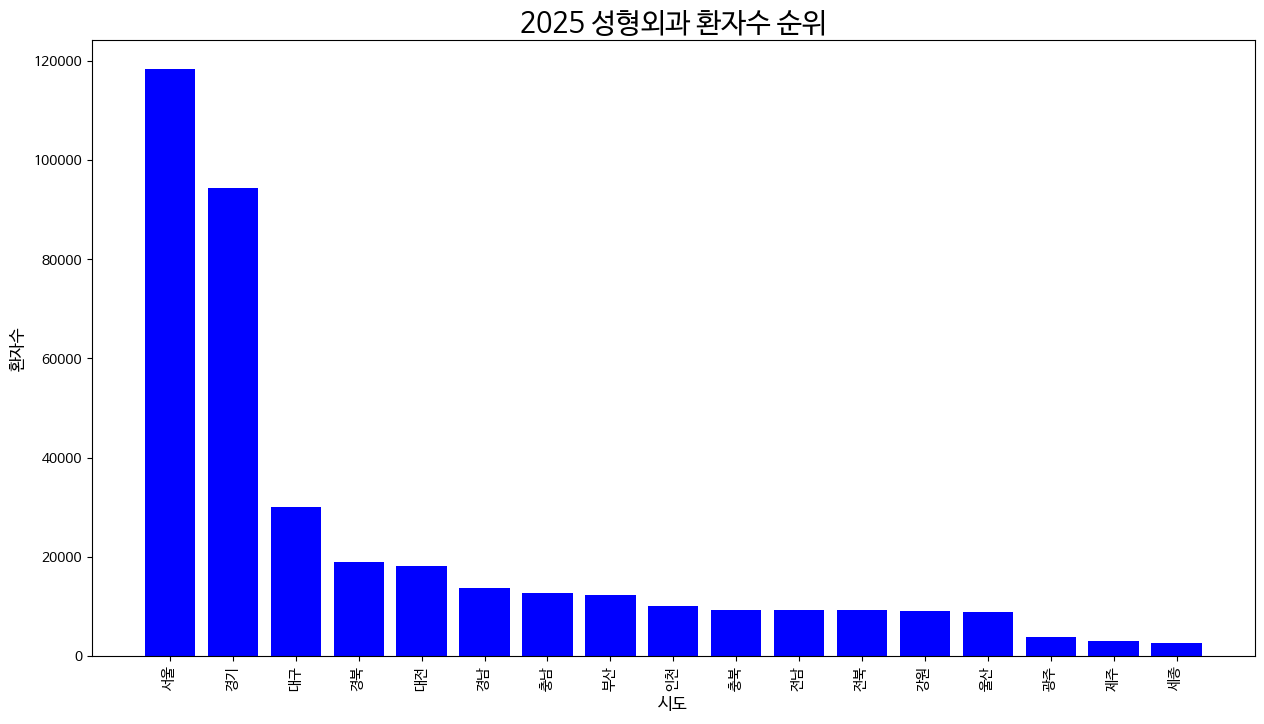

In [ ]:
#문제18번(4점)

plt.rc('font', family='NanumBarunGothic')
plt.figure(figsize=(15,8))
plt.bar(df2['시도'], df2['환자수'], color='blue')

plt.title('2025 성형외과 환자수 순위', fontsize=20)
plt.xlabel('시도', fontsize=12)
plt.ylabel('환자수',rotation='vertical',fontsize=12)
plt.xticks(rotation=90)
plt.show()
